In [2]:
# Import Libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar100
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [3]:
# Load Dataset

(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [4]:
# Use Smaller Dataset

x_train = x_train[:5000]
y_train = y_train[:5000]

x_test = x_test[:1000]
y_test = y_test[:1000]

print(x_train.shape)
print(x_test.shape)

(5000, 32, 32, 3)
(1000, 32, 32, 3)


In [5]:
# Resize Images for VGG16

IMG_SIZE = 224

x_train_resized = tf.image.resize(
    x_train,
    (IMG_SIZE, IMG_SIZE)
)

x_test_resized = tf.image.resize(
    x_test,
    (IMG_SIZE, IMG_SIZE)
)

x_train_resized = x_train_resized / 255.0
x_test_resized = x_test_resized / 255.0

In [6]:
# One hot Encoding

y_train_cat = to_categorical(y_train, 100)
y_test_cat = to_categorical(y_test, 100)

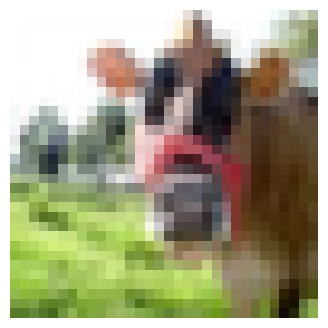

In [7]:
# Display Sample Image

plt.figure(figsize=(4,4))
plt.imshow(x_train[0])
plt.axis('off')
plt.show()

In [8]:
# Load VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [9]:
# Build Model

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

In [10]:
# Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          25,700 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,163,172 (80.73 MB)

 Trainable params: 6,448,484 (24.60 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
# Compile Model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Train Model

history = model.fit(
    x_train_resized,
    y_train_cat,
    validation_data=(x_test_resized, y_test_cat),
    epochs=1,
    batch_size=32
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2154s 14s/step - accuracy: 0.0102 - loss: 4.6741 - val_accuracy: 0.0090 - val_loss: 4.6052


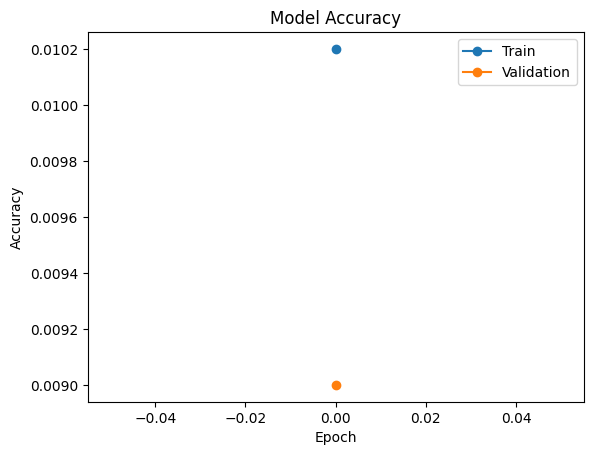

In [21]:
# Accuracy Plot

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

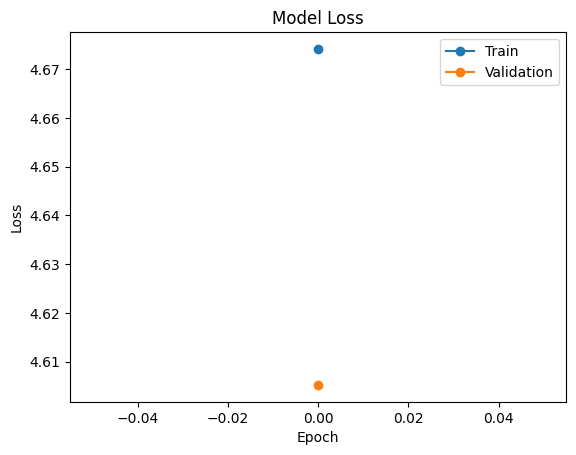

In [20]:
# Loss Plot

plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

In [15]:
# Evaluate Model


loss, accuracy = model.evaluate(
    x_test_resized,
    y_test_cat
)

print("Test Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 361s 11s/step - accuracy: 0.0090 - loss: 4.6052
Test Accuracy: 0.008999999612569809


In [16]:
# Predict One Image

prediction = model.predict(
    x_test_resized[:1]
)

predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)
print("Actual Class:", y_test[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: 64
Actual Class: 49
